## Module 3: Lung Fibrosis- Creating a New Lung Biopsy Device and Predictive Algorithm for Fibrotic Scarring

## Team Members:
Megan Sullivan and Ashley Hayden
## Project Title:
White Pixel Analysis of Lung Fibrosis Across Various Pulmonary Depths


## Project Goal:
The goal of this project is to use threshold-based image segmentation to quantify the amount of fibrosis in lung tissue at different depths by measuring the proportion of white pixels.
Our project seeks to answer the following questions: 
1) Does the proportion of white pixels (fibrosis) increase or decrease with lung tissue depth?
2) How can interpolation be used to predict the extent of fibrosis in the lung at different biopsy depths from the top of the lung?

Answering these questions will guide Intuitive's process of creating a new lung biopsy
device that can acquire biopsies at very specific and accurate depths into the lung. This will reduce excessive biopsy punch intervention and improve fibrotic lung examination efficiency.

## Disease Background: 

* Prevalence & incidence- relatively rare condition that affects about 200,000 people in the United States and is most commonly seen in older adults, with an incidence of roughly 5–10 cases per 100,000 people per year.

* Economic Burden- the disease creates a significant economic burden due to high healthcare costs, which are mainly driven by expensive medications, frequent hospitalizations, and long-term oxygen therapy.

* Risk factors (genetic, lifestyle)- include genetic predisposition such as family history and gene mutations, as well as lifestyle and environmental exposures like smoking and inhalation of dust from farming, construction, or metal work.

* Societal Dterminants- Social factors such as limited access to specialists, living in rural areas, and lower income or lack of insurance can delay diagnosis and treatment, leading to worse outcomes.

* Symptoms- progressive shortness of breath, a persistent dry cough, fatigue, unintentional weight loss, and clubbing of the fingers

* Diagnosis- made using high-resolution CT scans, lung function tests, and sometimes a lung biopsy, often involving a team of specialists 

* Standard of care treatment(s)- treatment focuses on slowing disease progression through antifibrotic medications like pirfenidone and nintedanib, along with oxygen therapy, pulmonary rehabilitation, and possibly lung transplantation, while insurance coverage often requires prior approval due to high costs

* Disease progression and diagnosis- The disease is progressive and worsens over time, with varying rates of decline, and  has an average survival of about 3–5 years after diagnosis.

* Continuum of Care Providers- Care involves a multidisciplinary team including primary care physicians, pulmonologists, ILD specialists, radiologists, pathologists, respiratory therapists, transplant teams, and palliative care providers

* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)-the disease is driven by repeated injury to the alveoli, leading to abnormal healing and excessive scar tissue formation, which causes the lungs to stiffen and reduces their ability to exchange oxygen

* Clinical Trials/Next-Gen Therapies- Ongoing research is focused on developing new antifibrotic drugs, inhaled therapies that directly target the lungs, and regenerative approaches to slow or potentially reverse fibrosis.

## Data-Set (Primary and Secondary): 
The primary data set was extracted from the Pierce-Cottler Lab in the Department of Biomedical Engineering and the Kim Lab in the Division of Pulmonary and Critical Care at the University of Virginia School of Medicine. These data have not been published yet and are considered “hot off the press. The data includes images of mouse model lung tissue captured at various depths. 
The data was collected via histological imaging of lung tissue samples from Bleomycin-induced Lung Injury Mouse Models. Bleomyosin is utilized as a chemotherapy that also causes lung fibrosis, so the antibiotic is injected into mouse models to represent human fibrotic lungs. The tissue was sectioned and imaged at different depths within the lung so researchers could determine how fibrosis changes throughout the tissue. Lung samples were fixed with formaldehyde, sliced with a cryotome, placed onto a microscopic slide, and immunostained for image analysis. The sections immunostained for 3 proteins of interest: desmin, smooth muscle alpha actin, and CD-31. Desmin, which represents the myofibroblasts that generate fibrotic scar tissue, was converted to a black and white image. White pixels represent areas of fibrosis. 
The main variables in this dataset are:
Depth (microns, µm): how deep into the lung the image was taken
White pixel percentage (%): what percentage of the image depicts fibrotic tissue
By looking at how the percentage of white pixels changes with depth, this dataset allows for a more quantitative way to understand how fibrosis is distributed in the lung.
(https://uvahealth.com/findadoctor/John-Kim-1407155682)

The secondary data set, used to confirm analysis methods used for the primary data set, was extracted from *Deep neural network based histological scoring of lung fibrosis and inflammation in the mouse model system* (Heinemann F, Birk G, Schoenberger T, Stierstorfer B. Deep neural network based histological scoring of lung fibrosis and inflammation in the mouse model system. PLoS One. 2018 Aug 23;13(8):e0202708. doi: 10.1371/journal.pone.0202708. PMID: 30138413; PMCID: PMC6107205.). Similar techniques were used in this data collection. Sections of fibrotic lung tissue from mice were stained with Masson Trichrome, which makes fibrotic tissue appear blue and other structures red or purple. The slide scans were captured at 20x magnification to produce quality images of fibrosis. The depths of slices were not noted. Folder 0 is important because it provides examples of normal tissue, helping the model learn the difference between healthy and diseased lungs. Folder 7 contains images with significant fibrotic mass.



## Data Analyis: 
**1a. Analyze Mouse Model Images from the Pierce-Cottler Lab and Kim Lab**


6 images from the primary data set were imported. An empty list was created to store the percentage of white pixels in each image. The python script then ran through each image, applied a binary threshold, and counted the number of white pixels. The respective filenames, depths, and white percents were then exported to a seperate csv file. 


In [7]:
import time  # New import for timing
from termcolor import colored
import cv2
import numpy as np
import pandas as pd

# Image filenames extracted from the provided directory, ensuring they are in the same order as the depths list
filenames = [
    r"/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_SK658 Slobe ch010136.jpg",
    r"/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_SK658 Slobe ch010129.jpg",
    r"/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_SK658 Slobe ch010119.jpg",
    r"/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010032.jpg",
    r"/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010071.jpg",
    r"/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_SK658 Slobe ch010113.jpg",
    r"/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_SK658 Slobe ch010107.jpg",
    r"/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_SK658 Slobe ch010149.jpg",
    r"/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010018.jpg",
    r"/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010039.jpg",
    r"/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010160.jpg",

]

# Depths corresponding to each image
depths = [9200, 3250, 8000, 500, 7100, 7300, 6300, 3350, 90, 15, 7200]

white_percents = [] # List to store the percentage of white pixels for each image
total_analysis_time = 0  # Variable to accumulate pure processing time

print(colored("Counts of pixel by color in each image", "yellow")) # Header for the output

for filename, depth in zip(filenames, depths): # Loop through each image and its corresponding depth
# (ChatGPT, 2026): The following code block processes each image to count the number of white and black pixels, calculates the percentage of white pixels, and prints the results. It also accumulates the processing time for each image to calculate the total analysis time at the end.

    # Load image in grayscale
    img = cv2.imread(filename, 0) 
    
    # Convert to binary
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Count pixels
    white = np.sum(binary == 255)
    black = np.sum(binary == 0)
    total = white + black

    white_percent = 100 * white / total # Calculate percentage of white pixels
    white_percents.append(white_percent) # Store the percentage in the list

    # Print results 
    print(colored(f"{filename}", "red"))
    print(colored(f"White pixels: {white}", "light_grey")) 
    print(colored(f"Black pixels: {black}", "dark_grey"))
    print(f"{white_percent:.2f}% White | Depth: {depth} microns\n") # Print the percentage of white pixels and the corresponding depth

# Save results to CSV
df = pd.DataFrame({
    "Filenames": filenames,
    "Depths": depths,
    "White percents": white_percents
})

df.to_csv("Percent_White_Pixels.csv", index=False) # Save the DataFrame to a CSV file without the index

print("-" * 30) # Separator for clarity in the output
print(f"The .csv file 'Percent_White_Pixels.csv' has been created.") # Confirmation message for the user


Counts of pixel by color in each image
/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_SK658 Slobe ch010136.jpg
White pixels: 163638
Black pixels: 4030666
3.90% White | Depth: 9200 microns

/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_SK658 Slobe ch010129.jpg
White pixels: 82784
Black pixels: 4111520
1.97% White | Depth: 3250 microns

/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_SK658 Slobe ch010119.jpg
White pixels: 137592
Black pixels: 4056712
3.28% White | Depth: 8000 microns

/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010032.jpg
White pixels: 48667
Black pixels: 4145637
1.16% White | Depth: 500 microns

/Users/megansullivan/Desktop/Comp BME/Sullivan-Hayden-Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010071.jpg
White pixels: 117756
Black pixels: 4076548
2.81% White | Depth: 7100 microns

/Users/megansullivan/Desktop/

**1b. Develop an algorithm that interpolates the amount of fibrosis
at a specific depth in sample lung tissue**

The following python script relies on interpolation techniques to accurately estimate the percentage of white pixels at a given depth. In the first example, linear extrapolation is used at a depth of 5000 microns. The function estimates that at 5000 microns, the percentage of white pixels is about 2.21%. In the second example, quadratic extrapolation is used at a depth of 5000 microns. The function estimates that at 5000 microns, the percentage of white pixels is about 2.04%.

The interpolated point is at the x-coordinate 5000.0 and y-coordinate 2.2130917694609042.


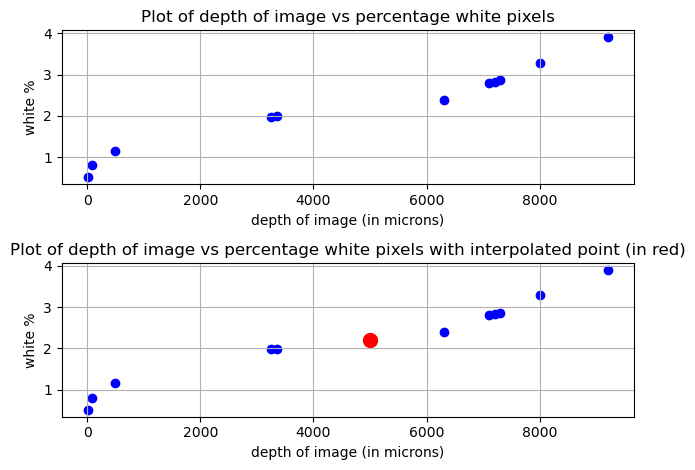

The interpolated point is at the x-coordinate 5000.0 and y-coordinate 2.0405296326949354.


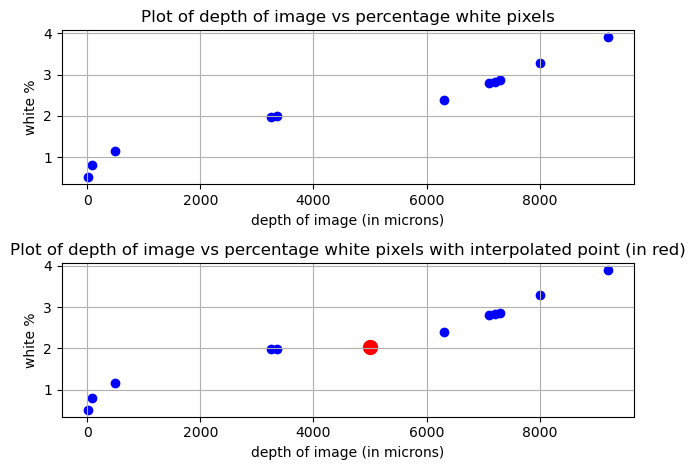

In [8]:
# Interpolate a point: given a depth, find the corresponding white pixel percentage
from scipy.interpolate import interp1d # Importing the interpolation function from scipy
import matplotlib.pyplot as plt # Importing matplotlib for plotting
interpolate_depth = float(input(colored(
    "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = white_percents

# You can also use 'quadratic', 'cubic', etc.
i = interp1d(x, y, kind='linear', fill_value="extrapolate") # Create the interpolation function based on the original data points
interpolate_point = i(interpolate_depth) # Use the interpolation function to find the corresponding white pixel percentage for the given depth
print(colored(
    f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:] # Create a copy of the original depths list to include the interpolated point
depths_i.append(interpolate_depth) # Append the interpolated depth to the list of depths
white_percents_i = white_percents[:] # Create a copy of the original white percentages list to include the interpolated point
white_percents_i.append(interpolate_point) # Append the interpolated white pixel percentage to the list of white percentages


# make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue') # Plot the original data points without the interpolated point
axs[0].set_title('Plot of depth of image vs percentage white pixels') 
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white %')
axs[0].grid(True) # Add grid for better visibility


axs[1].scatter(depths_i, white_percents_i, marker='o',
               linestyle='-', color='blue') # Plot the original data points along with the interpolated point
axs[1].set_title(
    'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white %')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
               color='red', s=100, label='Highlighted point') # Highlight the interpolated point in red


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

#QUADRATIC INTERPOLATION
x = depths
y = white_percents

# You can also use 'quadratic', 'cubic', etc.
i = interp1d(x, y, kind='quadratic', fill_value="extrapolate") # Create the interpolation function based on the original data points
interpolate_point = i(interpolate_depth) # Use the interpolation function to find the corresponding white pixel percentage for the given depth
print(colored(
    f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:] # Create a copy of the original depths list to include the interpolated point
depths_i.append(interpolate_depth) # Append the interpolated depth to the list of depths
white_percents_i = white_percents[:] # Create a copy of the original white percentages list to include the interpolated point
white_percents_i.append(interpolate_point) # Append the interpolated white pixel percentage to the list of white percentages


# make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue') # Plot the original data points without the interpolated point
axs[0].set_title('Plot of depth of image vs percentage white pixels') 
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white %')
axs[0].grid(True) # Add grid for better visibility


axs[1].scatter(depths_i, white_percents_i, marker='o',
               linestyle='-', color='blue') # Plot the original data points along with the interpolated point
axs[1].set_title(
    'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white %')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
               color='red', s=100, label='Highlighted point') # Highlight the interpolated point in red


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

**1c. Visualize the relationship between depth and white % in the primary data set**


To determine the strength of the relationship between the image depth and percentage of white pixels, a linear regression test was performed to visualize the curve and find an R^2 value.


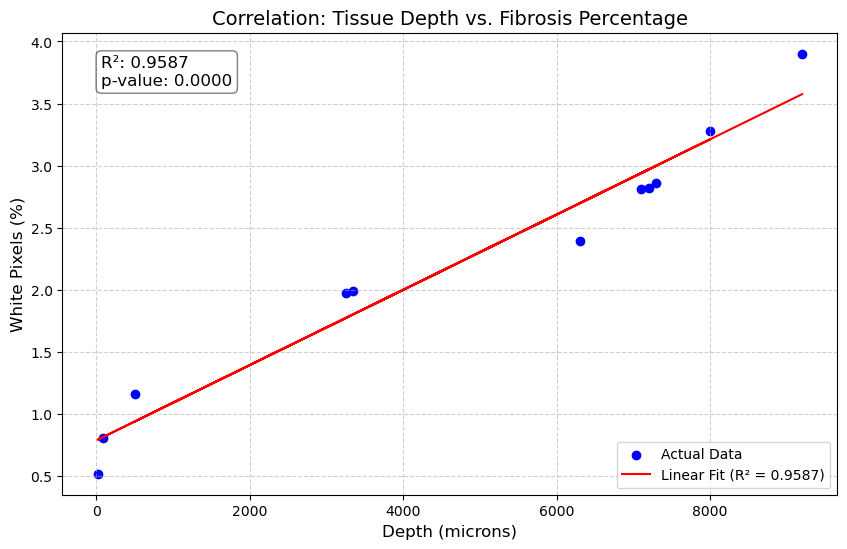

R-squared: 0.9587
P-value: 0.0000


In [9]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
#(ChatGPT, 2026): The following code block performs linear regression on the original data points (depths and white percentages), calculates the R-squared value and p-value, creates a regression line, and plots the original data points along with the regression line. It also includes a text box on the plot to display the R-squared and p-value for better visualization of the correlation between depth and percentage of white pixels.
# 1. Prepare and Sort Data
x = np.array(depths)
y = np.array(white_percents)

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Calculate R-squared
r_squared = r_value**2

# 2. Create the Regression Line
line = slope * x + intercept

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x, line, color='red', label=f'Linear Fit (R² = {r_squared:.4f})')

# Formatting
plt.title('Correlation: Tissue Depth vs. Fibrosis Percentage', fontsize=14)
plt.xlabel('Depth (microns)', fontsize=12)
plt.ylabel('White Pixels (%)', fontsize=12)

# Add text box for R^2 and P-value
stats_text = f'R²: {r_squared:.4f}\np-value: {p_value:.4f}'
plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
             fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.grid(True, linestyle='--', alpha=0.6) # Add grid for better visibility
plt.legend() 
plt.show()

print(f"R-squared: {r_squared:.4f}")
print(f"P-value: {p_value:.4f}")

**2a. Analyze an external data set to support analysis methods in Part 1**

To confirm that the analysis methods listed above provided accurate white % values for fibrotic lung images, a secondary data set was pulled from *Deep neural network based histological scoring of lung fibrosis and inflammation in the mouse model system* (Heinemann F, Birk G, Schoenberger T, Stierstorfer B. Deep neural network based histological scoring of lung fibrosis and inflammation in the mouse model system. PLoS One. 2018 Aug 23;13(8):e0202708. doi: 10.1371/journal.pone.0202708. PMID: 30138413; PMCID: PMC6107205.). The python script turns fibrotic scarring particles white for binary image analysis. The script then loops through 4,984 images of healthy lung samples (folder 0) and 288 samples with large fibrotic masses (folder 7). A comparitive boxplot is displayed to quanitfiy the differences in fibrotic lung white % versus healthy lung white %.

Although the displayed boxplots suggest higher white pixel %'s than the primary data set does, they still confirm the difference in fibrotic masses between healthy lungs and diseased lungs. Healthy lungs have a mean white percentage of 3.966504, while fibrotic lung has a mea white percentage of 12.247665. Differences in the Pierce-Cottler Lab and Kim Lab's thresholding techniques may explain the difference in the concentration of white pixels analyzed by the python script. Thus, the image analysis methods used in Part 1 are still reliable. 

Processing Healthy (Folder 0)...
Processing Fibrotic (Folder 7)...

COMPARISON SUMMARY
              Group      mean      std       max
Fibrotic (Folder 7) 12.247665 7.319172 40.226315
 Healthy (Folder 0)  3.966504 3.947349 26.935459


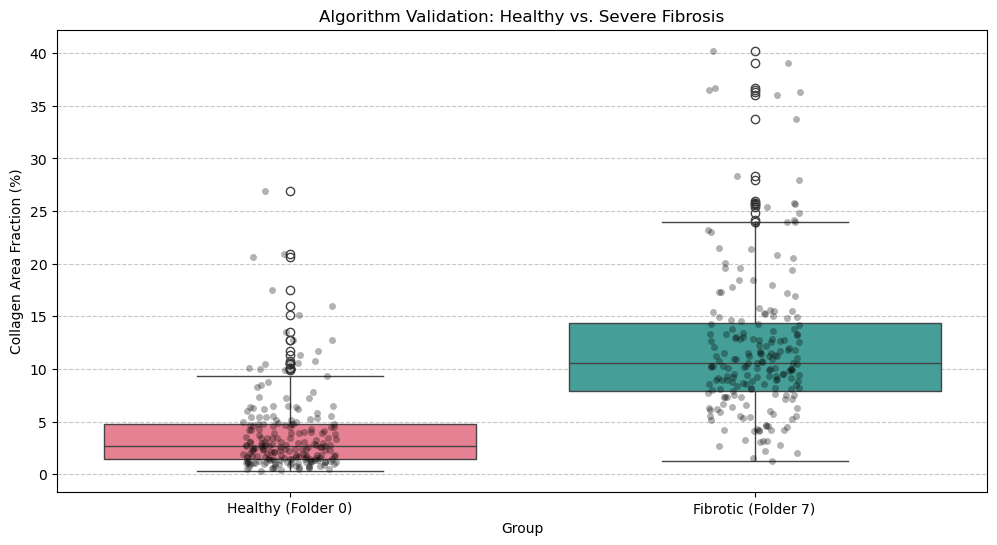

In [4]:
#SECONDARY DATA SET
#(ChatGPT, 2026): The following code block is designed to analyze a secondary dataset of histology images stained with Masson's Trichrome. It calculates the percentage of blue-stained collagen in each image, which is indicative of fibrosis. The results are printed and saved to a CSV file, and a distribution plot is generated to visualize the fibrosis percentages across the dataset.
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from termcolor import colored

import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from termcolor import colored

# --- 1. CONFIGURATION ---
# Update these paths to your local directories
folders = {
    "Healthy (Folder 0)": r"/Users/megansullivan/Downloads/Lung fibrosis (Ashcroft)/training/0",
    "Fibrotic (Folder 7)": r"/Users/megansullivan/Downloads/Lung fibrosis (Ashcroft)/training/7"
}

def analyze_trichrome_fibrosis(img_path):
    img = cv2.imread(img_path)
    if img is None: return None
    
    # Tissue Mask (Denominator)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, tissue_mask = cv2.threshold(gray, 230, 255, cv2.THRESH_BINARY_INV)
    tissue_area = np.sum(tissue_mask == 255)
    
    if tissue_area < 500: return None # Skip empty tiles

    # Collagen Mask (Numerator)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_blue = np.array([90, 60, 60]) 
    upper_blue = np.array([135, 255, 255])
    fibrosis_mask = cv2.inRange(hsv, lower_blue, upper_blue)
    
    # Clean noise with 3x3 kernel (Standard)
    kernel = np.ones((3,3), np.uint8)
    fibrosis_mask = cv2.morphologyEx(fibrosis_mask, cv2.MORPH_OPEN, kernel)
    
    blue_pixels = np.sum(fibrosis_mask == 255)
    return 100 * (blue_pixels / tissue_area)

# --- 2. EXECUTION ---
all_results = []

for label, path in folders.items():
    print(colored(f"Processing {label}...", "cyan"))
    search_pattern = os.path.join(path, "**", "*.png")
    files = glob.glob(search_pattern, recursive=True)[:200] # Subset for speed
    
    for f in files:
        val = analyze_trichrome_fibrosis(f)
        if val is not None:
            all_results.append({"Group": label, "Fibrosis_%": val})

# --- 3. STATISTICAL SUMMARY & PLOT ---
df = pd.DataFrame(all_results)

# Calculate Statistics
summary = df.groupby("Group")["Fibrosis_%"].agg(['mean', 'std', 'max']).reset_index()
print("\n" + "="*50)
print(colored("COMPARISON SUMMARY", "yellow", attrs=['bold']))
print(summary.to_string(index=False))
print("="*50)

# Visualization
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="Group", 
    y="Fibrosis_%", 
    data=df, 
    hue="Group",     # Explicitly tell Seaborn to color by Group
    palette="husl", 
    legend=False     # Hide the legend since the x-axis already labels the groups
)
sns.stripplot(x="Group", y="Fibrosis_%", data=df, color="black", alpha=0.3)
plt.title("Algorithm Validation: Healthy vs. Severe Fibrosis")
plt.ylabel("Collagen Area Fraction (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Verify and validate your analysis: 
A major question to be answered in this project is whether or not fibrotic mass increases deeper in the lung tissue. The python script and results for Part 1a supported the conclusion that fibrotic mass increases further down in the lung. Part 1c  confirmed this claim by generating a linear regression model with an R^2 value of .9587, which suggests a strong correlation between deeper tissue depth and higher fibrotic mass. After this conclusion was drawn, Part 1b used interpolation techniques to estimate the white % at certain depths, which would ultimately help design a medical device that can acquire biopsies at very specific and accurate depths. The calculated white % at a depth of 5000 microns makes sense compared to the white % values found in images taken at a known depth. For example, the white % at 5000 was calculated to be 2.2131% (linear) and 2.0405% (quadratic), and the white % at 6300 is known to be 2.3898%. Thus, the estimated white % values drawn from interpolation techniques are reliable and accurate. 

To confirm that the image analysis techniques used in Part 1 generated quality data, an external data source was used in Part 2, and similar analysis methods were applied to the set. Although the relative white %'s of both healthy lung tissue and fibrotic healthy lung tissue were elevated compared to the primary data set, there was still a clear difference in the white % of fibrotic lung and white % of healthy lung. Differences could be attributed to how both teams of researchers filtered/procesessed their images. Thus, it can still be concluded that fibrotic tissue increases with deeper biopsy punches, and fibrotic lungs demonstrate irregular scarring that healthy lungs lack.

## Conclusions and Ethical Implications: 
Parts 1 and 2 answered the overarching question of whether fibrotic scarring increases deeper in lung tissue. In the provided mouse model images,fibrotic scarring proved to increase deeper in tissue, proving solid framework for designing a new lung biopsy device. Furthermore, the accurate interpolation methods carried out in Part 1b can be used to predict the extent of fibrosis at different biopsy lenghts, which prevents excessive biopsy punches from being made. As a result, our medical device company, Intuitive, can create a new lung biopsy device that acquires biopsies at specific depths and avoids excess/unecessary biopsy punches. The algorithm created by the interpolation code will insetad predict fibrotic scar tissue values, and physicians can mimimize biopsy intervention.

Ethical implications include the reliability of mouse models and the accuracy of the interpolation methods. Mice lungs differ in anatomy from human lungs due to their small size, different arrangment of lobes, thinner alveoli, etc. Thus, it is possible that creating a new lung biopsy device for humans that was based off of rodent data could cause harm. Humans may experience slightly different fibrotic patterns in deeper lung tissue than mice, which could lead to incorrect predictions and inadequate care. The employed interpolation methods may not be accurate enough, leading to potential misdianoses. For example, interpolation could predict that scarring is less severe than it truly is, leading to insufficient patient care.

Company recommendation: Due to increasing fibrotic scarring in deeper lung tissue depths, the device should be designed with a variable-length needle capable of reaching 10000 microns to ensure it captures a patient's densest fibrotic region. This allows physicians to accurately determine the extent of fibrotic scarring in a patient and provide adequate levels of care.


## Limitations and Future Work: 
Major limitations in this project include differences in mice and human anatomy, interpolation accuracy, and 2D image analysis. Since mice and human differ grealty in their pathophysiology, it is likely that human lung fibrosis data must be analyzed to produce a safe lung biopsy device and accurate depth/fibrotic scar tissue algorithm. Mice data is insufficient in supporting the production of a product that would be approved by the FDA, so future work would involve retrieving human fibrotic lung tissue samples to study. Interpolation techniques are also a critical limitation of this project, as the true accuracy of the algorithm is unknown. Each pulmonary lung fibrosis patient has unique fibrotic scarring, so interpolated points may not be completely accurate in identifying the amount of scarring at certain tissue depths. Future work involves analyzing more mice lung images to improve the accuracy and precision of the interpolation methods. The 2D histology slices also create a project limitation, as 2D representations of fibrotic tissue may not accurately represent the amount of fibrotic scarring at a certain depth. For example, in an image at 5000 microns, one area of the lung may be severely scarred while the other parts are relatively healthy, which produces a "false negative." Future work may involve "stacking" the 2D images on top of each other (image registration) and performing 3D analysis to determine the continuity of scar patches.

## References:
1) https://uvahealth.com/findadoctor/John-Kim-1407155682
2) *Deep neural network based histological scoring of lung fibrosis and inflammation in the mouse model system* (Heinemann F, Birk G, Schoenberger T, Stierstorfer B. Deep neural network based histological scoring of lung fibrosis and inflammation in the mouse model system. PLoS One. 2018 Aug 23;13(8):e0202708. doi: 10.1371/journal.pone.0202708. PMID: 30138413; PMCID: PMC6107205.)
